## 1 · Load raw data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── file → (position label, r_cm, theta_deg) ─────────────────────────────────
FILE_META = {
    "BfieldMapData/gm2_set_7.csv": ("Center",         0.0,  0),
    "BfieldMapData/gm2_set_8.csv": ("Southwest edge", 10.0, 225),
    "BfieldMapData/gm2_set_9.csv": ("East edge",      10.0, 0),
}

COLORS = {
    "Center":         "steelblue",
    "Southwest edge": "darkorange",
    "East edge":      "seagreen",
}

dfs = []
for fpath, (label, r, theta) in FILE_META.items():
    df = pd.read_csv(fpath, comment="#", sep=",", names=["Time", "Field"])
    df["Time"]      = pd.to_timedelta(df["Time"])
    df["Time_s"]    = df["Time"].dt.total_seconds()
    df["PosLabel"]  = label
    df["r_cm"]      = r
    df["theta_deg"] = theta
    df["z_cm"]      = np.nan
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(data):,} rows across {data['PosLabel'].nunique()} positions.")
data.head()


Loaded 1,321 rows across 3 positions.


,Time,Field,Time_s,PosLabel,r_cm,theta_deg,z_cm
0,0 days 00:00:00,2.6,0.000,Center,0.0,0,NaN
1,0 days 00:00:00.256000,2.6,0.256,Center,0.0,0,NaN
2,0 days 00:00:00.512000,2.7,0.512,Center,0.0,0,NaN
3,0 days 00:00:00.752000,2.7,0.752,Center,0.0,0,NaN
4,0 days 00:00:01.007000,2.5,1.007,Center,0.0,0,NaN


## 2 · B vs Time (raw)

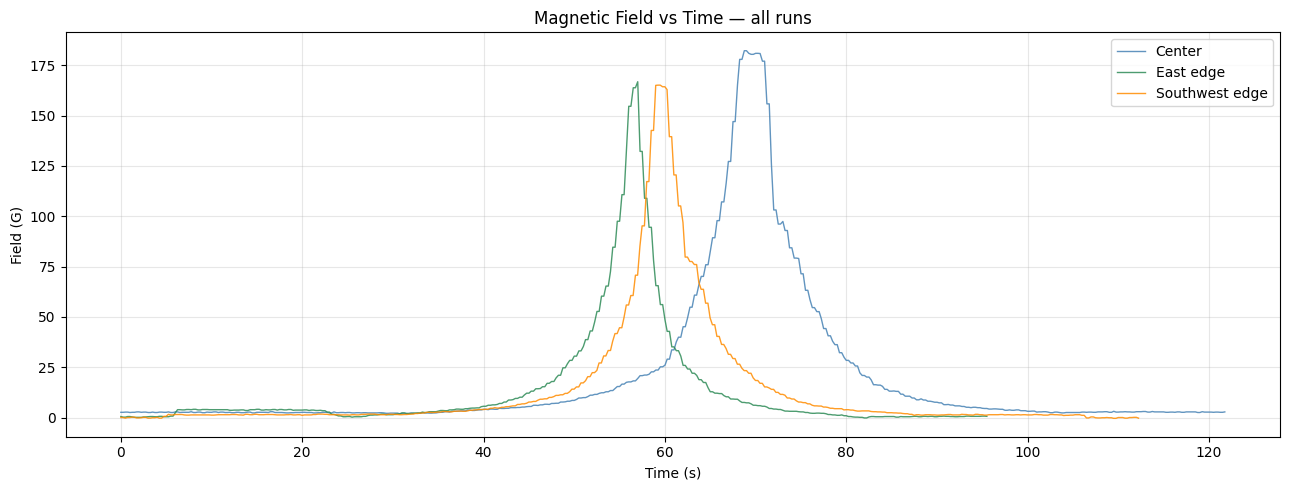

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

for label, grp in data.groupby("PosLabel"):
    ax.plot(grp["Time_s"], grp["Field"],
            color=COLORS[label], alpha=0.85, lw=1, label=label)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Field (G)")
ax.set_title("Magnetic Field vs Time — all runs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("BvsTime.png", dpi=300, bbox_inches="tight")
plt.show()


## 3 · Z-position tables (from video sync)

In [ ]:
# Each row = (z_cm recorded at that timestamp from video)
# Probe moves IN (z decreasing 24→0) then OUT (z increasing 0→max)

zpos7 = pd.DataFrame({
    "zposition": [
        24,23,22,21,20,19,18,17,16,15,14,13,12,11,10,
        9,8,7,6,5,4,3,2,1,0,1,2,3,4,5,6,7,8,9,10,11,12,
        13,14,15,16,17,18,19,20,21,22,23,24
    ],
    "time_str": [
        "00:28","00:29","00:31","00:33","00:35","00:37",
        "00:39","00:40","00:42","00:44","00:45","00:47","00:48",
        "00:50","00:51","00:53","00:54","00:56","00:58","01:00",
        "01:01","01:03","01:05","01:06","01:08","01:11","01:13",
        "01:15","01:17","01:19","01:20","01:23","01:24","01:26",
        "01:28","01:29","01:31","01:32","01:33","01:35","01:36",
        "01:38","01:40","01:41","01:42","01:44","01:46","01:47",
        "01:49"
    ]
})

zpos8 = pd.DataFrame({
    "zposition": [
        21,20,19,18,17,16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0,
        1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
    ],
    "time_str": [
        "00:28.7","00:30.2","00:31.2","00:33.2","00:35.2","00:36.2",
        "00:38.3","00:39.2","00:41.2","00:42.2","00:43.2","00:44.2",
        "00:45.2","00:47.2","00:49.2","00:50.2","00:51.3","00:52.2",
        "00:54.0","00:55.2","00:56.2","00:58.2","01:01.2","01:03.2",
        "01:04.3","01:06.3","01:07.2","01:09.0","01:10.2","01:11.2",
        "01:13.2","01:14.2","01:16.2","01:17.3","01:18.2","01:20.0",
        "01:21.2","01:22.2","01:24.2","01:25.2","01:26.2","01:28.2",
        "01:29.2"
    ]
})

zpos9 = pd.DataFrame({
    "zposition": [
        24,23,22,21,20,19,18,17,16,15,14,13,12,11,10,9,8,7,6,5,
        4,3,2,1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
    ],
    "time_str": [
        "00:20.3","00:23.0","00:24.0","00:26.0","00:27.0","00:29.0",
        "00:31.0","00:33.0","00:34.0","00:35.3","00:36.5","00:38.0",
        "00:39.3","00:41.0","00:42.0","00:44.0","00:45.3","00:47.0",
        "00:48.0","00:50.0","00:51.0","00:53.0","00:54.3","00:56.0",
        "00:57.0","00:58.0","00:59.3","01:01.0","01:02.3","01:03.3",
        "01:04.3","01:05.5","01:06.8","01:07.3","01:08.3","01:09.3",
        "01:10.0","01:11.3","01:12.3","01:14.0","01:15.0","01:16.0",
        "01:17.0","01:18.3","01:20.3","01:21.3"
    ]
})

ZPOS = {
    "Center":         zpos7,
    "Southwest edge": zpos8,
    "East edge":      zpos9,
}

## Additional step to check hysterisis

In [39]:
# ── Forward / Backward speed comparison in the 0–10 cm zone ──────────────────
# Paste this into a new cell at the end of your notebook.
# Requires: ZPOS dict already defined (Cell 3)

import numpy as np

print("=== Keyframe timestamps in the z=0–10 cm zone (forward and backward) ===\n")

for label, zdf in ZPOS.items():
    zdf = zdf.copy()
    zdf["Time_s"] = pd.to_timedelta("00:" + zdf["time_str"]).dt.total_seconds()

    # turnaround = first occurrence of z=0
    turn_idx = zdf[zdf["zposition"] == 0].index[0]

    fwd = zdf.loc[:turn_idx][zdf.loc[:turn_idx]["zposition"] <= 10].copy()
    bwd = zdf.loc[turn_idx:][zdf.loc[turn_idx:]["zposition"] <= 10].copy()

    print(f"--- {label} ---")
    print(f"  Forward  (z=10→0)  t = {fwd['Time_s'].values} s   z = {fwd['zposition'].values} cm")
    print(f"  Backward (z=0→10)  t = {bwd['Time_s'].values} s   z = {bwd['zposition'].values} cm")

    if len(fwd) >= 2:
        fwd_duration = fwd["Time_s"].max() - fwd["Time_s"].min()
        fwd_speeds   = np.abs(np.diff(fwd["zposition"].values[::-1]) /
                              np.diff(fwd["Time_s"].values))
        print(f"  Forward  time in zone : {fwd_duration:.1f} s")
        print(f"  Forward  speed (cm/s) : mean={fwd_speeds.mean():.3f}  "
              f"min={fwd_speeds.min():.3f}  max={fwd_speeds.max():.3f}")

    if len(bwd) >= 2:
        bwd_duration = bwd["Time_s"].max() - bwd["Time_s"].min()
        bwd_speeds   = np.abs(np.diff(bwd["zposition"].values) /
                              np.diff(bwd["Time_s"].values))
        print(f"  Backward time in zone : {bwd_duration:.1f} s")
        print(f"  Backward speed (cm/s) : mean={bwd_speeds.mean():.3f}  "
              f"min={bwd_speeds.min():.3f}  max={bwd_speeds.max():.3f}")
    print()

=== Keyframe timestamps in the z=0–10 cm zone (forward and backward) ===

--- Center ---
  Forward  (z=10→0)  t = [51. 53. 54. 56. 58. 60. 61. 63. 65. 66. 68.] s   z = [10  9  8  7  6  5  4  3  2  1  0] cm
  Backward (z=0→10)  t = [68. 71. 73. 75. 77. 79. 80. 83. 84. 86. 88.] s   z = [ 0  1  2  3  4  5  6  7  8  9 10] cm
  Forward  time in zone : 17.0 s
  Forward  speed (cm/s) : mean=0.650  min=0.500  max=1.000
  Backward time in zone : 20.0 s
  Backward speed (cm/s) : mean=0.567  min=0.333  max=1.000

--- Southwest edge ---
  Forward  (z=10→0)  t = [44.2 45.2 47.2 49.2 50.2 51.3 52.2 54.  55.2 56.2 58.2] s   z = [10  9  8  7  6  5  4  3  2  1  0] cm
  Backward (z=0→10)  t = [58.2 61.2 63.2 64.3 66.3 67.2 69.  70.2 71.2 73.2 74.2] s   z = [ 0  1  2  3  4  5  6  7  8  9 10] cm
  Forward  time in zone : 14.0 s
  Forward  speed (cm/s) : mean=0.791  min=0.500  max=1.111
  Backward time in zone : 16.0 s
  Backward speed (cm/s) : mean=0.724  min=0.333  max=1.111

--- East edge ---
  Forward 

## 4 · Interpolate z from timestamps

In [15]:
def assign_z(data, zpos_df, pos_label):
    """Interpolate z_cm for one run using video-sync timestamps."""
    zdf = zpos_df.copy()
    zdf["Time_s"] = pd.to_timedelta("00:" + zdf["time_str"]).dt.total_seconds()

    mask = data["PosLabel"] == pos_label
    t_s  = data.loc[mask, "Time_s"].values

    data.loc[mask, "z_cm"] = np.interp(
        t_s,
        zdf["Time_s"].values,
        zdf["zposition"].values
    )

for label, zdf in ZPOS.items():
    assign_z(data, zdf, label)

print("z_cm assigned. NaN count:", data["z_cm"].isna().sum())
data[["PosLabel","Time_s","Field","z_cm"]].head(10)


z_cm assigned. NaN count: 0


,PosLabel,Time_s,Field,z_cm
0,Center,0.000,2.6,24.0
1,Center,0.256,2.6,24.0
2,Center,0.512,2.7,24.0
3,Center,0.752,2.7,24.0
4,Center,1.007,2.5,24.0
5,Center,1.263,2.6,24.0
6,Center,1.503,2.6,24.0
7,Center,1.759,2.8,24.0
8,Center,1.999,2.8,24.0
9,Center,2.255,2.6,24.0


## 5 · Split each run into Forward and Backward passes

The turning point is the **peak B value** (`argmax(B)`) — the most reliable
reference because z=0 is approximate from video sync.

- **Forward** : probe entering solenoid, z decreasing, B increasing → up to peak  
- **Backward**: probe exiting solenoid, z increasing, B decreasing → from peak onward


In [16]:
fwd_data = {}   # label → DataFrame
bwd_data = {}

for label, grp in data.groupby("PosLabel"):
    grp = grp.reset_index(drop=True)
    peak_idx = grp["Field"].idxmax()

    fwd = grp.loc[:peak_idx].copy()
    bwd = grp.loc[peak_idx:].copy()

    # sort both by z so plots run left→right
    fwd = fwd.sort_values("z_cm").reset_index(drop=True)
    bwd = bwd.sort_values("z_cm").reset_index(drop=True)

    fwd_data[label] = fwd
    bwd_data[label] = bwd

    print(f"{label:20s}  peak @ idx={peak_idx}  "
          f"fwd rows={len(fwd)}  bwd rows={len(bwd)}  "
          f"peak B={grp.loc[peak_idx,'Field']:.1f} G  "
          f"z_cm @ peak={grp.loc[peak_idx,'z_cm']:.2f}")


Center                peak @ idx=275  fwd rows=276  bwd rows=213  peak B=182.2 G  z_cm @ peak=0.25
East edge             peak @ idx=228  fwd rows=229  bwd rows=155  peak B=166.8 G  z_cm @ peak=0.01
Southwest edge        peak @ idx=237  fwd rows=238  bwd rows=213  peak B=165.1 G  z_cm @ peak=0.35


## 6 · B vs z — Forward and Backward

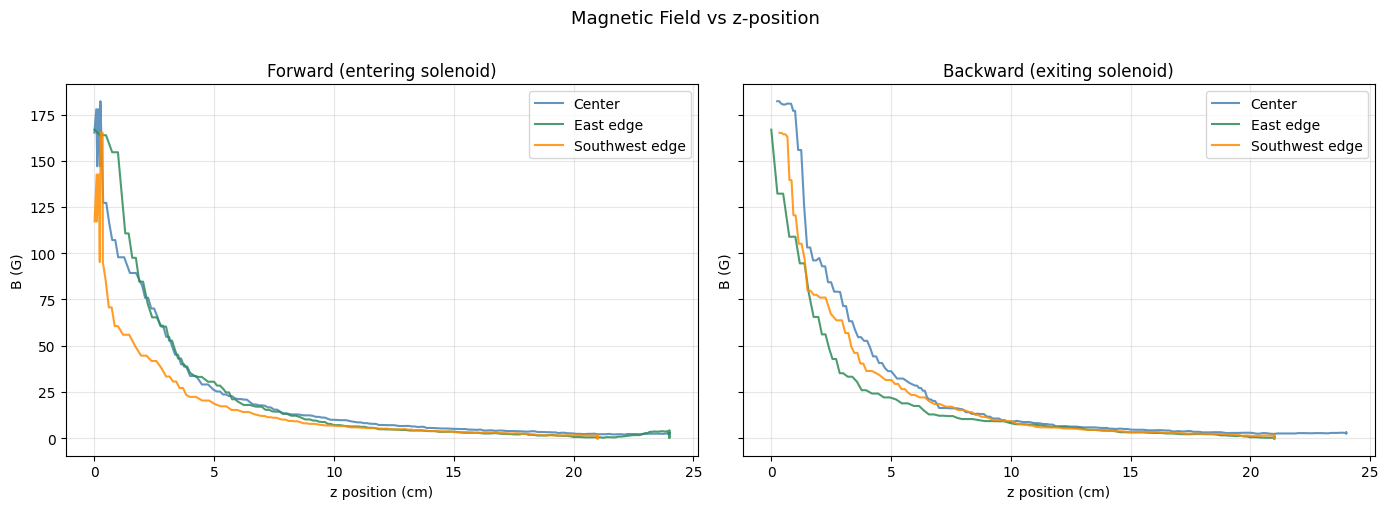

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles = ["Forward (entering solenoid)", "Backward (exiting solenoid)"]
datasets = [fwd_data, bwd_data]

for ax, ds, title in zip(axes, datasets, titles):
    for label, df in ds.items():
        ax.plot(df["z_cm"], df["Field"],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)
    ax.set_xlabel("z position (cm)")
    ax.set_ylabel("B (G)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Magnetic Field vs z-position", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("BvsZ.png", dpi=300, bbox_inches="tight")
plt.show()


## 7 · Central-difference gradient helper

In [18]:
def central_diff(z, B):
    """
    Before differentiating: bin B by z (0.5 cm bins) to get a clean B(z).
    Then apply 2nd-order central differences.
    Returns z_binned, dBdz arrays (only finite values).
    """
    z = z.astype(float)
    B = B.astype(float)

    # bin by z in 0.5 cm steps
    bins = np.arange(np.floor(z.min()), np.ceil(z.max()) + 0.5, 0.5)
    idx  = np.digitize(z, bins)
    z_b, B_b = [], []
    for i in range(1, len(bins)):
        mask = idx == i
        if mask.sum() > 0:
            z_b.append(z[mask].mean())
            B_b.append(B[mask].mean())

    z_b = np.array(z_b)
    B_b = np.array(B_b)
    n   = len(z_b)

    dBdz = np.full(n, np.nan)

    # interior: central difference
    dz_c = z_b[2:] - z_b[:-2]
    dz_c[dz_c == 0] = np.nan
    dBdz[1:-1] = (B_b[2:] - B_b[:-2]) / dz_c

    # boundaries: one-sided
    dz_l = z_b[1] - z_b[0]
    dz_r = z_b[-1] - z_b[-2]
    if dz_l != 0: dBdz[0]  = (B_b[1]  - B_b[0])  / dz_l
    if dz_r != 0: dBdz[-1] = (B_b[-1] - B_b[-2]) / dz_r

    return z_b, dBdz   # now returns z too since bins may differ from input z

## 8 · dB/dz vs z — Forward and Backward

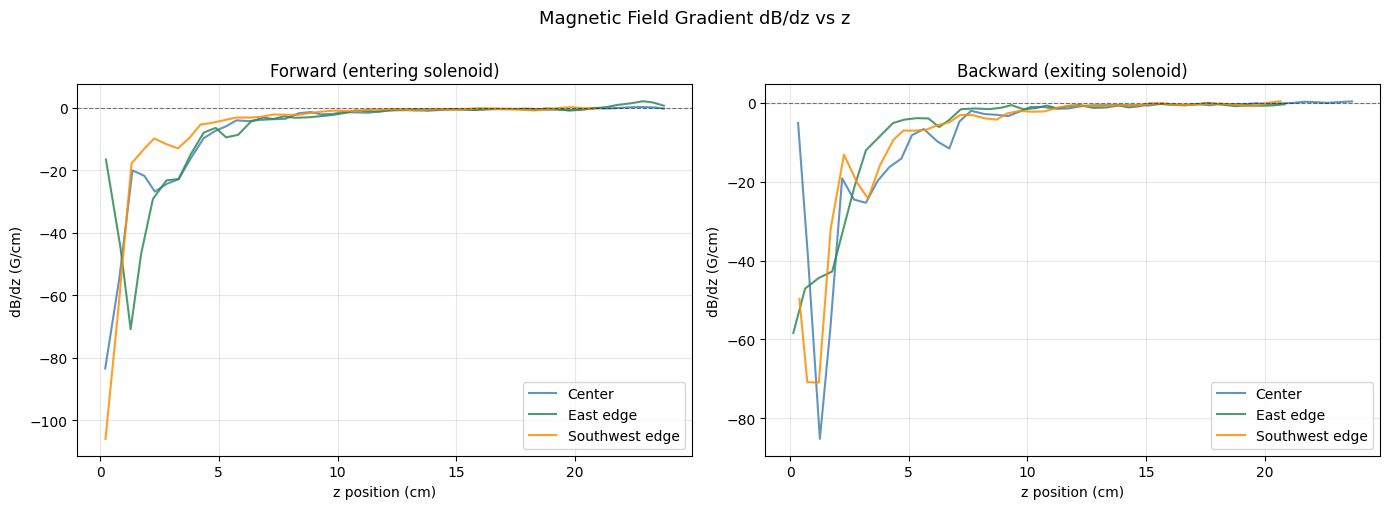

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # no sharey
titles   = ["Forward (entering solenoid)", "Backward (exiting solenoid)"]
datasets = [fwd_data, bwd_data]

for ax, ds, title in zip(axes, datasets, titles):
    for label, df in ds.items():
        z_b, dBdz = central_diff(df["z_cm"].values, df["Field"].values)
        ok = np.isfinite(dBdz)
        ax.plot(z_b[ok], dBdz[ok],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("z position (cm)")
    ax.set_ylabel("dB/dz (G/cm)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Magnetic Field Gradient dB/dz vs z", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("gradBvsZ.png", dpi=300, bbox_inches="tight")
plt.show()

## 9 · B · dB/dz vs z — Forward and Backward

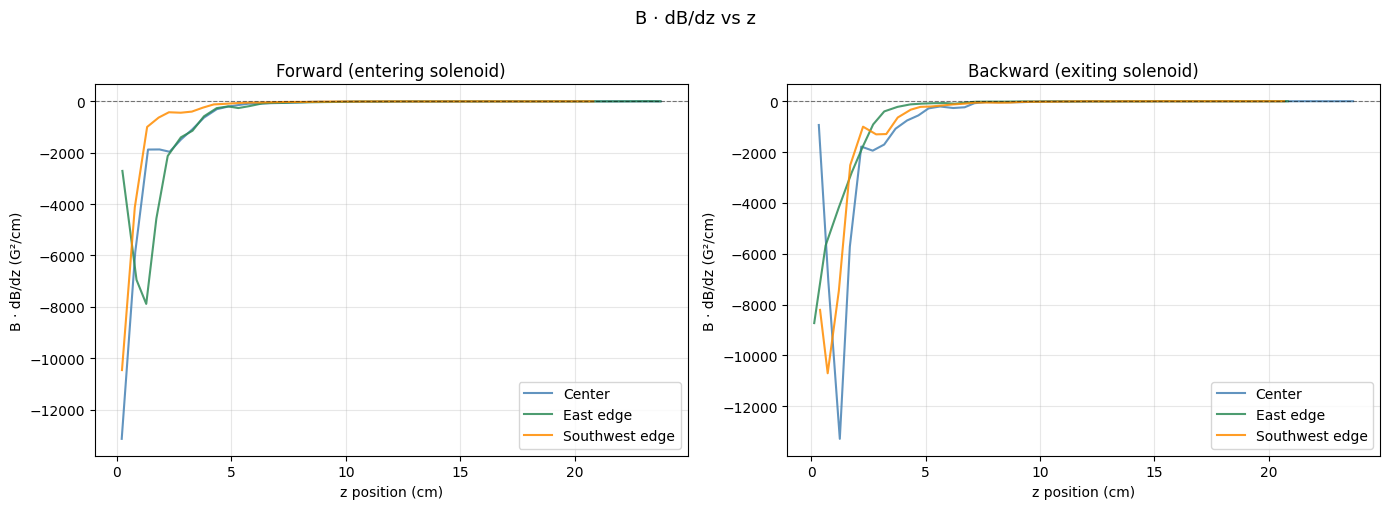

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # no sharey

for ax, ds, title in zip(axes, datasets, titles):
    for label, df in ds.items():
        z_b, dBdz  = central_diff(df["z_cm"].values, df["Field"].values)
        B_binned   = np.interp(z_b, df["z_cm"].values, df["Field"].values)
        BgradB     = B_binned * dBdz

        ok = np.isfinite(BgradB)
        ax.plot(z_b[ok], BgradB[ok],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("z position (cm)")
    ax.set_ylabel("B · dB/dz (G²/cm)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("B · dB/dz vs z", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("BgradBvsZ.png", dpi=300, bbox_inches="tight")
plt.show()

## 10 · Summary

In [21]:

import textwrap

POSITIONS = {
    'Center':         'r=0 cm  (on-axis)',
    'Southwest edge': 'r=10 cm, θ=225°',
    'East edge':      'r=10 cm, θ=0°',
}

summary_rows = []

for label, fwd_df in fwd_data.items():
    bwd_df = bwd_data[label]

    for pass_name, df in [('Forward', fwd_df), ('Backward', bwd_df)]:
        z   = df["z_cm"].values
        B   = df["Field"].values

        # ── Max B ──────────────────────────────────────────────────────────
        idx_maxB   = np.argmax(np.abs(B))
        max_B      = B[idx_maxB]
        pos_maxB   = z[idx_maxB]

        # ── Gradient ───────────────────────────────────────────────────────
        z_b, dBdz = central_diff(z, B)
        ok         = np.isfinite(dBdz)
        if ok.sum() == 0:
            continue
        idx_maxG   = np.nanargmax(np.abs(dBdz[ok]))
        max_grad   = dBdz[ok][idx_maxG]
        pos_maxG   = z_b[ok][idx_maxG]

        # ── B·dB/dz ────────────────────────────────────────────────────────
        B_at_zb    = np.interp(z_b, z, B)
        BgradB     = B_at_zb * dBdz
        ok2        = np.isfinite(BgradB)
        idx_maxBg  = np.nanargmax(np.abs(BgradB[ok2]))
        max_BgradB = BgradB[ok2][idx_maxBg]
        pos_maxBg  = z_b[ok2][idx_maxBg]

        # ── General behaviour ──────────────────────────────────────────────
        B_range    = B.max() - B.min()
        if pass_name == 'Forward':
            trend = 'rises' if (B[-1] > B[0]) else 'falls'
        else:
            trend = 'falls' if (B[0] > B[-1]) else 'rises'
        behaviour  = (f"B {trend} by {B_range:.1f} G over '"
                      f"{z.min():.1f}–{z.max():.1f} cm'")

        summary_rows.append({
            'label':      label,
            'position':   POSITIONS[label],
            'pass':       pass_name,
            'max_B_G':    max_B,
            'pos_maxB_cm': pos_maxB,
            'max_gradB_Gcm': max_grad,
            'pos_maxG_cm':   pos_maxG,
            'max_BgradB_G2cm': max_BgradB,
            'pos_maxBg_cm':    pos_maxBg,
            'behaviour':  behaviour,
        })

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'':-<110}")
print(f"{'Label':<18} {'Position':<22} {'Pass':<9}  "
      f"{'max|B|(G)':<11} {'@z(cm)':<8}  "
      f"{'max|dB/dz|(G/cm)':<19} {'@z(cm)':<8}  "
      f"{'max|B·dB/dz|(G²/cm)':<21} {'@z(cm)':<8}")
print(f"{'':-<110}")
for r in summary_rows:
    print(f"{r['label']:<18} {r['position']:<22} {r['pass']:<9}  "
          f"{abs(r['max_B_G']):<11.1f} {r['pos_maxB_cm']:<8.2f}  "
          f"{abs(r['max_gradB_Gcm']):<19.3f} {r['pos_maxG_cm']:<8.2f}  "
          f"{abs(r['max_BgradB_G2cm']):<21.3f} {r['pos_maxBg_cm']:<8.2f}")
print(f"{'':-<110}")
print()

# ── General behaviour ─────────────────────────────────────────────────────────
print("General behaviour:")
for r in summary_rows:
    print(f"  {r['label']:<18} {r['pass']:<9}  {r['behaviour']}")

# ── DataFrame for reuse ───────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
summary_df


--------------------------------------------------------------------------------------------------------------
Label              Position               Pass       max|B|(G)   @z(cm)    max|dB/dz|(G/cm)    @z(cm)    max|B·dB/dz|(G²/cm)   @z(cm)  
--------------------------------------------------------------------------------------------------------------
Center             r=0 cm  (on-axis)      Forward    182.2       0.25      83.475              0.22      13138.439             0.22    
Center             r=0 cm  (on-axis)      Backward   182.2       0.25      85.229              1.25      13278.689             1.25    
East edge          r=10 cm, θ=0°          Forward    166.8       0.01      70.902              1.29      7885.136              1.29    
East edge          r=10 cm, θ=0°          Backward   166.8       0.01      58.367              0.13      8725.857              0.13    
Southwest edge     r=10 cm, θ=225°        Forward    165.1       0.35      106.024             0.2

,label,position,pass,max_B_G,pos_maxB_cm,max_gradB_Gcm,pos_maxG_cm,max_BgradB_G2cm,pos_maxBg_cm,behaviour
0,Center,r=0 cm (on-axis),Forward,182.2,0.253333,-83.474950,0.218104,-13138.438829,0.218104,B falls by 180.3 G over '0.0–24.0 cm'
1,Center,r=0 cm (on-axis),Backward,182.2,0.253333,-85.229066,1.252667,-13278.688550,1.252667,B falls by 179.9 G over '0.3–24.0 cm'
2,East edge,"r=10 cm, θ=0°",Forward,166.8,0.006000,-70.902298,1.288824,-7885.135625,1.288824,B falls by 166.7 G over '0.0–24.0 cm'
3,East edge,"r=10 cm, θ=0°",Backward,166.8,0.006000,-58.366935,0.134000,-8725.856855,0.134000,B falls by 167.0 G over '0.0–21.0 cm'
4,Southwest edge,"r=10 cm, θ=225°",Forward,165.1,0.349000,-106.023578,0.229759,-10461.915499,0.229759,B falls by 165.4 G over '0.0–21.0 cm'
5,Southwest edge,"r=10 cm, θ=225°",Backward,165.1,0.349000,-70.933461,1.210625,-10699.714590,0.722944,B falls by 165.5 G over '0.3–21.0 cm'


## Publish like format for all relevant Figures

In [22]:
label_size = 16
fig_labelsize = 32

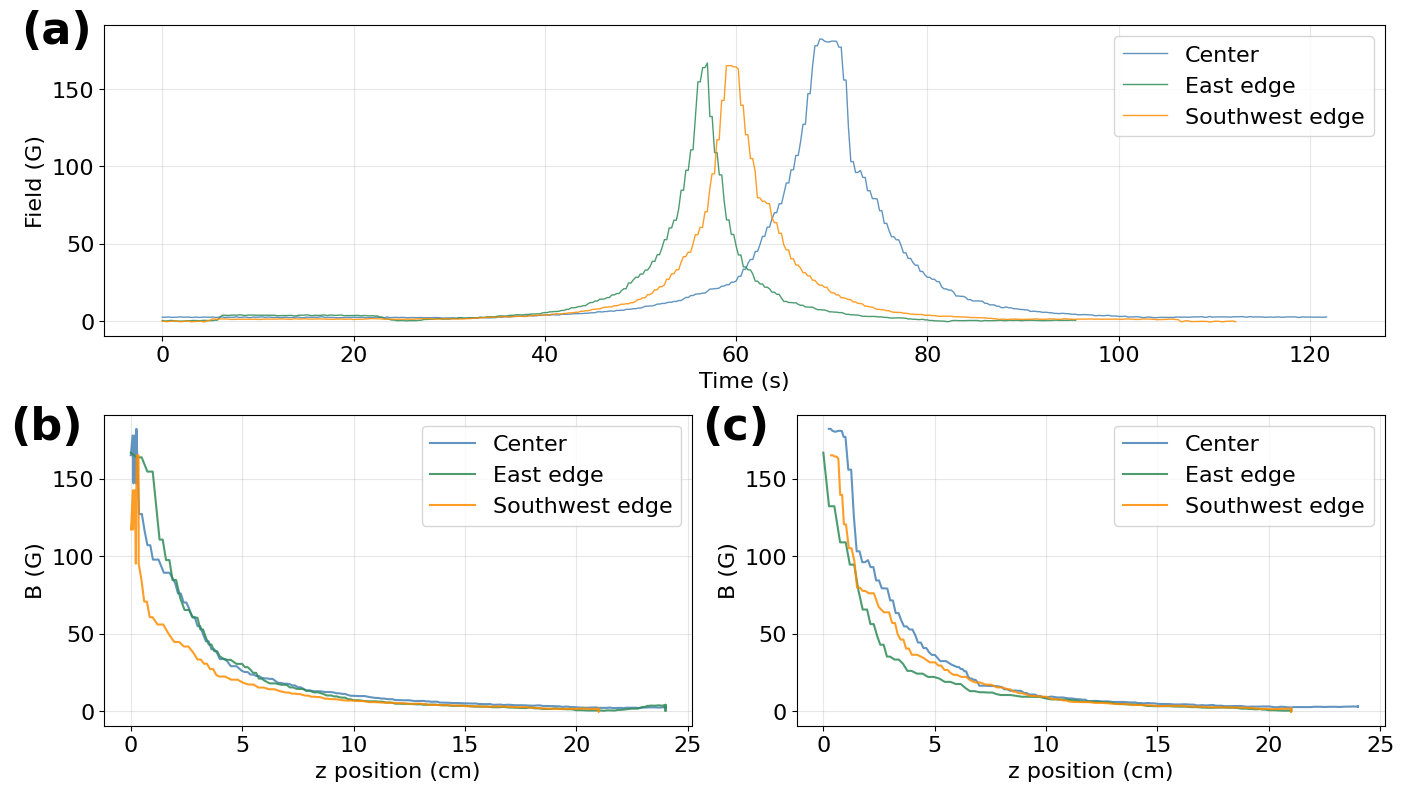

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# ---------- (a) Top plot ----------
ax_top = fig.add_subplot(gs[0, :])

for label, grp in data.groupby("PosLabel"):
    ax_top.plot(grp["Time_s"], grp["Field"],
                color=COLORS[label], alpha=0.85, lw=1, label=label)

ax_top.tick_params(axis='both', labelsize=label_size)
ax_top.set_xlabel("Time (s)", fontsize=label_size)
ax_top.set_ylabel("Field (G)", fontsize=label_size)
ax_top.grid(True, alpha=0.3)
ax_top.legend(fontsize=label_size)

ax_top.text(-0.065, 1.05, "(a)", transform=ax_top.transAxes,
            fontsize=fig_labelsize, fontweight='bold',
            va='top', ha='left')


# ---------- (b) and (c) Bottom plots ----------
axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1])
]

labels = ["(b)", "(c)"]
datasets = [fwd_data, bwd_data]

for ax, ds, lab in zip(axes, datasets, labels):
    for label, df in ds.items():
        ax.plot(df["z_cm"], df["Field"],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)

    ax.tick_params(axis='both', labelsize=label_size)
    ax.set_xlabel("z position (cm)", fontsize=label_size)
    ax.set_ylabel("B (G)", fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=label_size)

    ax.text(-0.16, 1.03, lab, transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold',
            va='top', ha='left')


plt.tight_layout()
plt.savefig("combined_figure41.png", dpi=300, bbox_inches="tight")
plt.show()

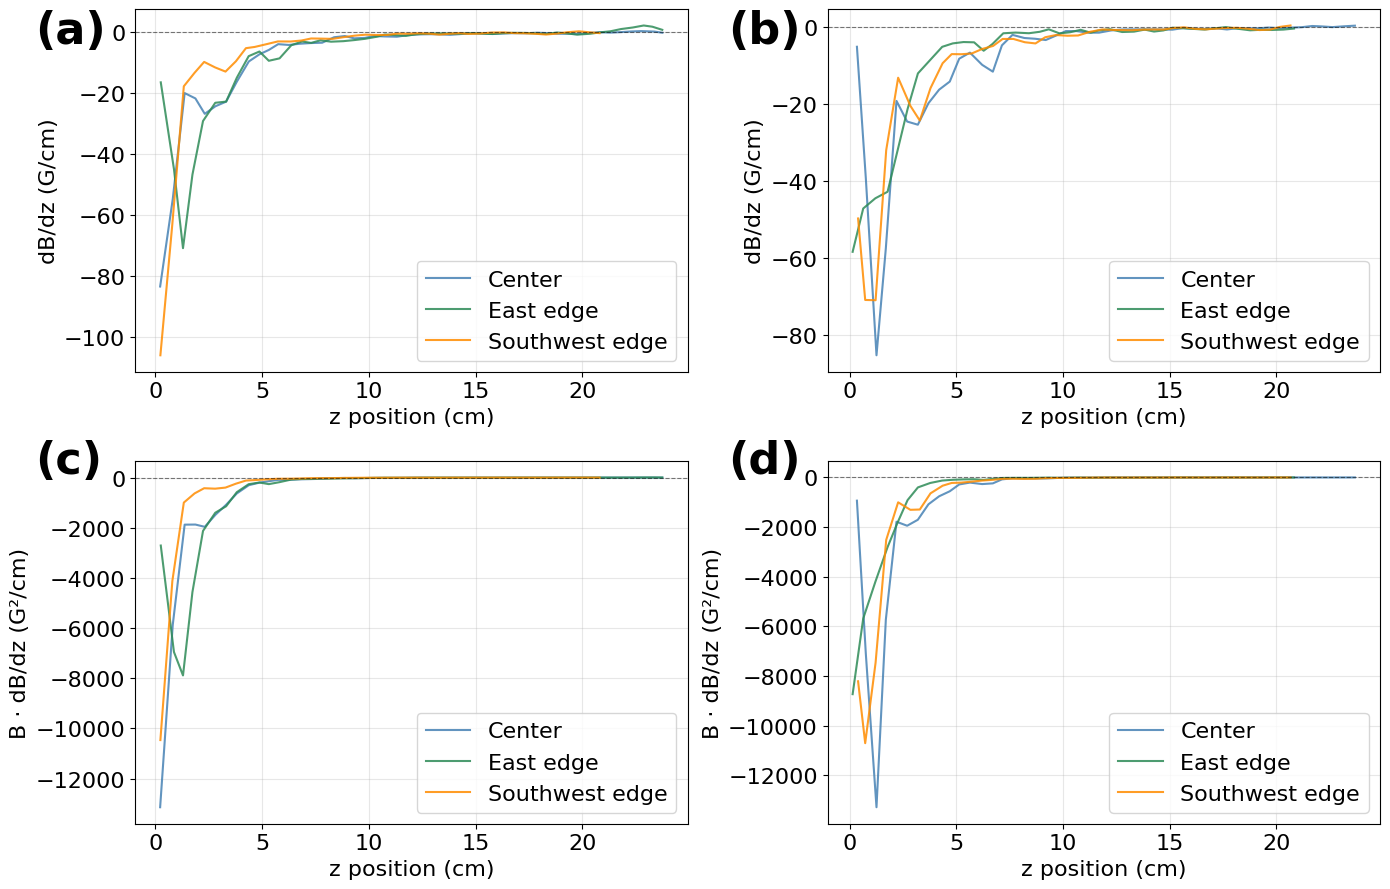

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

datasets = [fwd_data, bwd_data]
panel_labels = [["(a)", "(b)"], ["(c)", "(d)"]]

# ---------- Top row: dB/dz ----------
for j, (ds, lab) in enumerate(zip(datasets, panel_labels[0])):
    ax = axes[0, j]

    for label, df in ds.items():
        z_b, dBdz = central_diff(df["z_cm"].values, df["Field"].values)
        ok = np.isfinite(dBdz)

        ax.plot(z_b[ok], dBdz[ok],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)

    ax.tick_params(axis='both', labelsize=label_size)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("z position (cm)", fontsize=label_size)
    ax.set_ylabel("dB/dz (G/cm)", fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=label_size)

    ax.text(-0.18, 1.0, lab, transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold',
            va='top', ha='left')


# ---------- Bottom row: B * dB/dz ----------
for j, (ds, lab) in enumerate(zip(datasets, panel_labels[1])):
    ax = axes[1, j]

    for label, df in ds.items():
        z_b, dBdz = central_diff(df["z_cm"].values, df["Field"].values)
        B_binned = np.interp(z_b, df["z_cm"].values, df["Field"].values)
        BgradB = B_binned * dBdz

        ok = np.isfinite(BgradB)

        ax.plot(z_b[ok], BgradB[ok],
                color=COLORS[label], lw=1.5, alpha=0.85, label=label)

    ax.tick_params(axis='both', labelsize=label_size)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("z position (cm)", fontsize=label_size)
    ax.set_ylabel("B · dB/dz (G²/cm)", fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=label_size)

    ax.text(-0.18, 1.06, lab, transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold',
            va='top', ha='left')


plt.tight_layout()
plt.savefig("combined_gradients42.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
zdf = zpos7.copy()
zdf["Time_s"] = pd.to_timedelta("00:" + zdf["time_str"]).dt.total_seconds()
zdf["dz"] = zdf["zposition"].diff().abs()
zdf["dt"] = zdf["Time_s"].diff()
zdf["speed_cm_s"] = zdf["dz"] / zdf["dt"]
print(zdf[["zposition", "Time_s", "speed_cm_s"]])

    zposition  Time_s  speed_cm_s
0          24    28.0         NaN
1          23    29.0    1.000000
2          22    31.0    0.500000
3          21    33.0    0.500000
4          20    35.0    0.500000
5          19    37.0    0.500000
6          18    39.0    0.500000
7          17    40.0    1.000000
8          16    42.0    0.500000
9          15    44.0    0.500000
10         14    45.0    1.000000
11         13    47.0    0.500000
12         12    48.0    1.000000
13         11    50.0    0.500000
14         10    51.0    1.000000
15          9    53.0    0.500000
16          8    54.0    1.000000
17          7    56.0    0.500000
18          6    58.0    0.500000
19          5    60.0    0.500000
20          4    61.0    1.000000
21          3    63.0    0.500000
22          2    65.0    0.500000
23          1    66.0    1.000000
24          0    68.0    0.500000
25          1    71.0    0.333333
26          2    73.0    0.500000
27          3    75.0    0.500000
28          4 

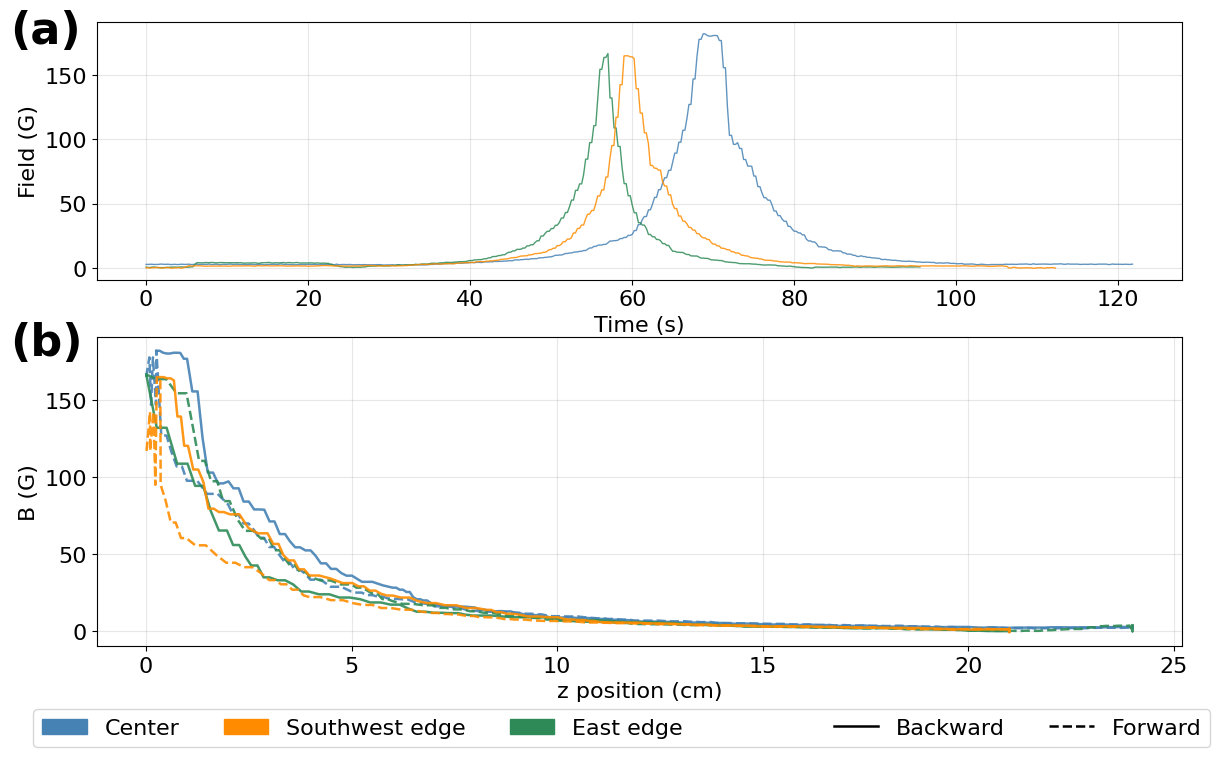

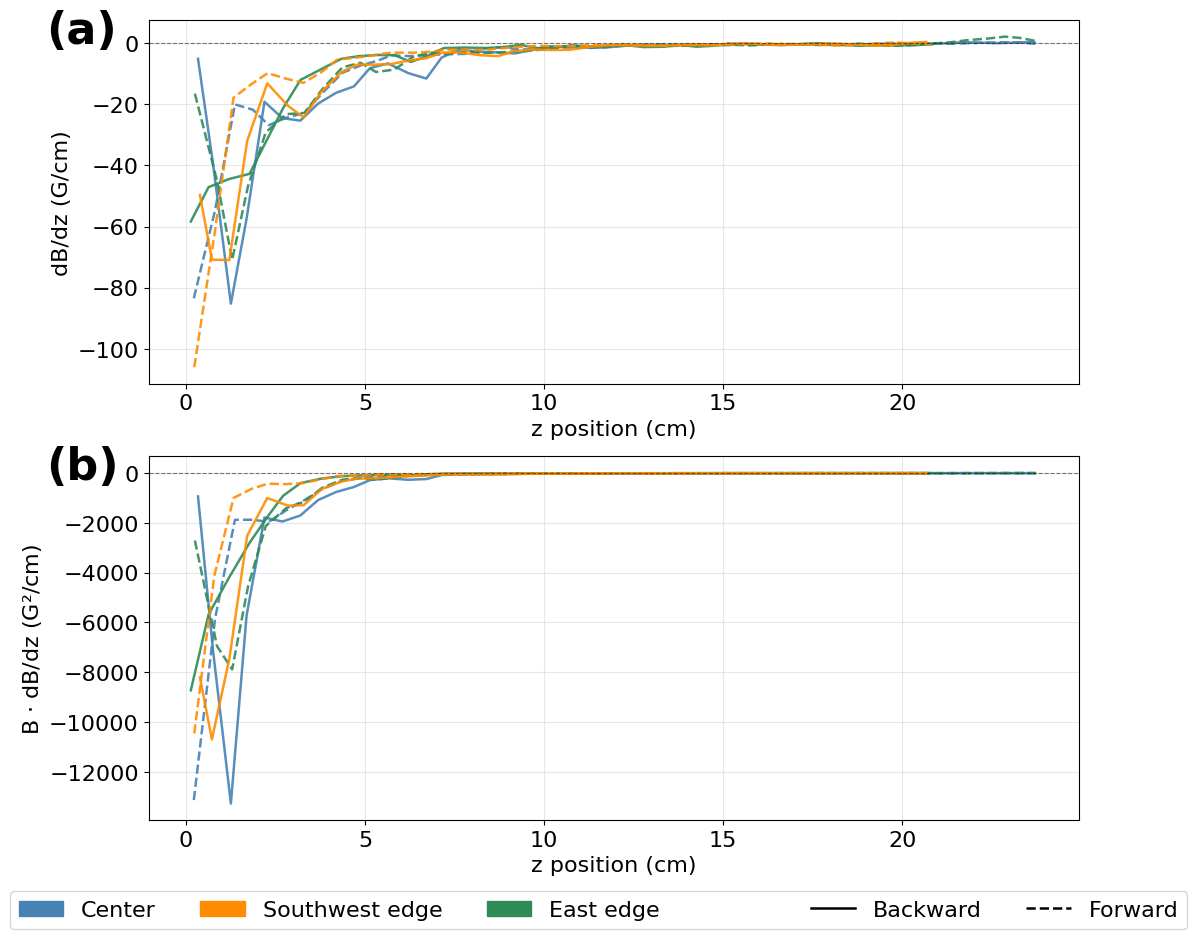

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

label_size = 16
fig_labelsize = 32

# ── shared legend builder ─────────────────────────────────────────────────────
def make_shared_legend(fig, colors_dict, label_size, bottom_adjust=0.10):
    """
    Adds a single shared legend below all panels.
    Top row: position (color patches — Center, East edge, Southwest edge)
    Bottom row: direction (linestyle — Forward dashed, Backward solid)
    """
    position_handles = [
        mpatches.Patch(color=c, label=lbl)
        for lbl, c in colors_dict.items()
    ]
    direction_handles = [
        Line2D([0], [0], color='k', lw=1.8, ls='-',  label='Backward'),
        Line2D([0], [0], color='k', lw=1.8, ls='--', label='Forward'),
    ]
    # Two legend rows: positions on left group, directions on right group
    all_handles = position_handles + [
        Line2D([0],[0], color='none', label='')   # spacer
    ] + direction_handles

    fig.legend(
        handles=all_handles,
        loc='lower center',
        ncol=len(position_handles) + 1 + len(direction_handles),
        fontsize=label_size,
        frameon=True,
        bbox_to_anchor=(0.5, -0.04),
    )
    fig.subplots_adjust(bottom=bottom_adjust)


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 41 — B vs Time (top) + B vs z overlaid (bottom)
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# ---------- (a) B vs Time ----------
ax_top = fig.add_subplot(gs[0])

for label, grp in data.groupby("PosLabel"):
    ax_top.plot(grp["Time_s"], grp["Field"],
                color=COLORS[label], alpha=0.85, lw=1)

ax_top.tick_params(axis='both', labelsize=label_size)
ax_top.set_xlabel("Time (s)", fontsize=label_size)
ax_top.set_ylabel("Field (G)", fontsize=label_size)
ax_top.grid(True, alpha=0.3)
ax_top.text(-0.08, 1.05, "(a)", transform=ax_top.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

# ---------- (b) B vs z — both passes overlaid ----------
ax_bot = fig.add_subplot(gs[1])

for label in fwd_data:
    c = COLORS[label]
    ax_bot.plot(fwd_data[label]["z_cm"], fwd_data[label]["Field"],
                color=c, lw=1.8, ls='--', alpha=0.9)
    ax_bot.plot(bwd_data[label]["z_cm"], bwd_data[label]["Field"],
                color=c, lw=1.8, ls='-',  alpha=0.9)

ax_bot.tick_params(axis='both', labelsize=label_size)
ax_bot.set_xlabel("z position (cm)", fontsize=label_size)
ax_bot.set_ylabel("B (G)", fontsize=label_size)
ax_bot.grid(True, alpha=0.3)
ax_bot.text(-0.08, 1.05, "(b)", transform=ax_bot.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

make_shared_legend(fig, COLORS, label_size, bottom_adjust=0.10)
plt.savefig("combined_figure41.png", dpi=300, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 42 — dB/dz (top) + B·dB/dz (bottom), both passes overlaid
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ylabels     = ["dB/dz (G/cm)", r"B $\cdot$ dB/dz (G²/cm)"]
panel_labs  = ["(a)", "(b)"]

for row, (ax, ylab, plab) in enumerate(zip(axes, ylabels, panel_labs)):
    for label in fwd_data:
        fdf = fwd_data[label]
        bdf = bwd_data[label]
        c   = COLORS[label]

        z_f, dBdz_f = central_diff(fdf["z_cm"].values, fdf["Field"].values)
        z_b, dBdz_b = central_diff(bdf["z_cm"].values, bdf["Field"].values)
        ok_f = np.isfinite(dBdz_f)
        ok_b = np.isfinite(dBdz_b)

        if row == 0:
            ax.plot(z_f[ok_f], dBdz_f[ok_f], color=c, lw=1.8, ls='--', alpha=0.9)
            ax.plot(z_b[ok_b], dBdz_b[ok_b], color=c, lw=1.8, ls='-',  alpha=0.9)
        else:
            B_f   = np.interp(z_f, fdf["z_cm"].values, fdf["Field"].values)
            B_b   = np.interp(z_b, bdf["z_cm"].values, bdf["Field"].values)
            BgB_f = B_f * dBdz_f
            BgB_b = B_b * dBdz_b
            ok_f2 = np.isfinite(BgB_f)
            ok_b2 = np.isfinite(BgB_b)
            ax.plot(z_f[ok_f2], BgB_f[ok_f2], color=c, lw=1.8, ls='--', alpha=0.9)
            ax.plot(z_b[ok_b2], BgB_b[ok_b2], color=c, lw=1.8, ls='-',  alpha=0.9)

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=label_size)
    ax.set_xlabel("z position (cm)", fontsize=label_size)
    ax.set_ylabel(ylab, fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.text(-0.11, 1.03, plab, transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

make_shared_legend(fig, COLORS, label_size, bottom_adjust=0.08)
plt.savefig("combined_gradients42.png", dpi=300, bbox_inches="tight")
plt.show()